# 13 - Synthetic benchmark generation: a stage-by-stage walkthrough

## tl;dr

The synthetic benchmark is not a black box: it is a fixed sequence of 8
generation stages, each with an explicit, documented distribution or rule.
This notebook runs a small demo world through every stage with the real
generator code (`src/boamp/synthetic/*`) and plots what that stage actually
produces, so the mechanism is visible rather than just described.

Stages covered: buyers -> establishments -> needs -> cycles (the
survival-time step) -> relations (event/censoring) -> notices ->
corruption/noise -> export. See
`docs/synthetic_benchmark_dgp_specification.md` for the authoritative spec
this notebook illustrates.

This is a **demo run**, not a benchmark replicate: it uses a much smaller
`n_buyers` than the released benchmark (`config/synthetic/benchmark_defaults_v0_1.yaml`
targets 2,000 buyers) purely so the stage-by-stage plots render quickly, and
it does not write into `data/processed/synthetic_benchmark/`.


## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

from boamp.reporting.figures import setup_style
from boamp.synthetic.missingness import assign_quality_class, SEVERITY_MULTIPLIER, DURATION_SEVERITY_MULTIPLIER
from boamp.synthetic.pipeline import generate_clean_world, generate_observed_world
from boamp.synthetic.scenarios import load_benchmark_defaults, load_scenario

setup_style()

SCENARIO_ID = "central_provisional"
N_BUYERS_DEMO = 800          # released benchmark uses 2,000 -- kept small here for a fast, readable demo
WORLD_SEED = 20260721
CORRUPTION_SEED = 20260722

# dataviz-skill reference palette (also already this repo's real-vs-synthetic
# convention: blue/orange are the same hexes as COLOR_REAL/COLOR_SYN elsewhere)
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
GRID = "#e1e0d9"
GOOD, WARN, CRIT = "#0ca30c", "#fab219", "#d03b3b"

scenario = load_scenario(PROJECT_ROOT, SCENARIO_ID)
benchmark_defaults = load_benchmark_defaults(PROJECT_ROOT)
observation_end = pd.Timestamp(benchmark_defaults.observation_window.end_date)

world = generate_clean_world(SCENARIO_ID, PROJECT_ROOT, n_buyers=N_BUYERS_DEMO, world_seed=WORLD_SEED)
observed, corruption_log = generate_observed_world(world, SCENARIO_ID, PROJECT_ROOT, corruption_seed=CORRUPTION_SEED)

buyers = world["buyers"]
establishments = world["establishments"]
needs = world["needs"]
cycles = world["cycles"]
true_relations = world["true_relations"]
notice_family_membership = world["notice_family_membership"]
clean_notices = world["clean_notices"]

for name, df in [("buyers", buyers), ("establishments", establishments), ("needs", needs),
                 ("cycles", cycles), ("true_relations", true_relations),
                 ("clean_notices", clean_notices), ("observed_notices", observed),
                 ("corruption_log", corruption_log)]:
    print(f"{name:20s} {len(df):>6,d} rows")

buyers                  800 rows
establishments          868 rows
needs                 1,768 rows
cycles                2,600 rows
true_relations        2,600 rows
clean_notices         3,606 rows
observed_notices      3,606 rows
corruption_log       10,257 rows


## Stage 1 - Buyers: a heavy-tailed activity population

Every buyer's `activity_rate` is drawn from a Pareto distribution
(`buyers.py::generate_latent_buyers`, shape=`buyers.activity_pareto_shape`
in the scenario config) and normalized to sum to 1. This is deliberately
heavy-tailed: a small number of buyers (large communes, hospital centers)
account for a large share of all activity, matching the real corpus's
buyer-concentration Gini (~0.83, `calib_buyer_concentration_lorenz.csv`).
`activity_tier` (`21+` / `6-20` / `2-5`) is then just the 99th/80th
percentile cut of that same draw, not a separate assignment.

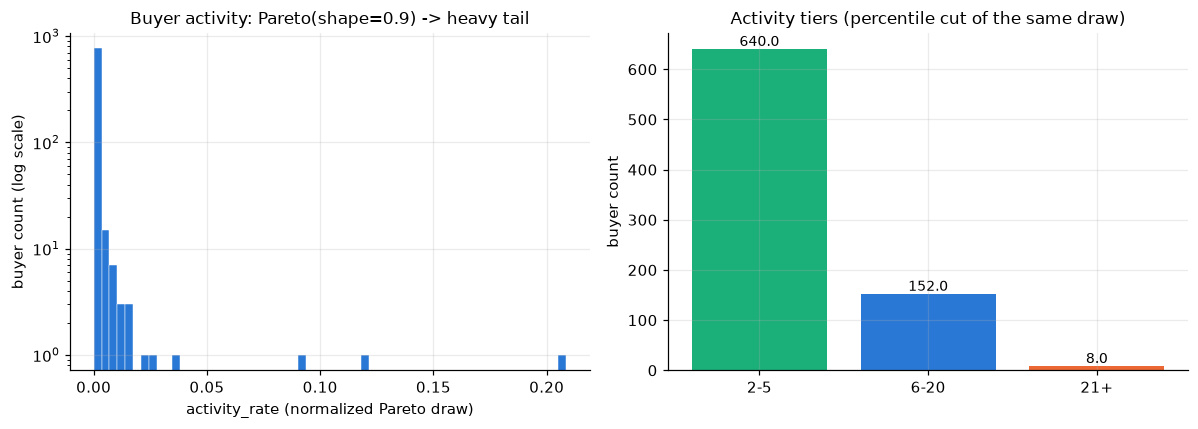

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(buyers["activity_rate"], bins=60, color=BLUE, edgecolor="white", linewidth=0.3)
axes[0].set_yscale("log")
axes[0].set_xlabel("activity_rate (normalized Pareto draw)")
axes[0].set_ylabel("buyer count (log scale)")
axes[0].set_title(f"Buyer activity: Pareto(shape={scenario.buyers.activity_pareto_shape}) -> heavy tail")

tier_order = ["1", "2-5", "6-20", "21+"]
tier_counts = buyers["activity_tier"].value_counts().reindex(tier_order).dropna()
axes[1].bar(tier_counts.index, tier_counts.values, color=[AQUA, BLUE, ORANGE, YELLOW][:len(tier_counts)])
axes[1].set_title("Activity tiers (percentile cut of the same draw)")
axes[1].set_ylabel("buyer count")
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Stage 2 - Establishments: SIRETs under each buyer

Each buyer gets one or more establishments (`establishments.py`), the
entities that actually hold a valid SIRET under the buyer's SIREN. This is
a thin fan-out step -- the interesting shape (activity concentration) was
already fixed at Stage 1.

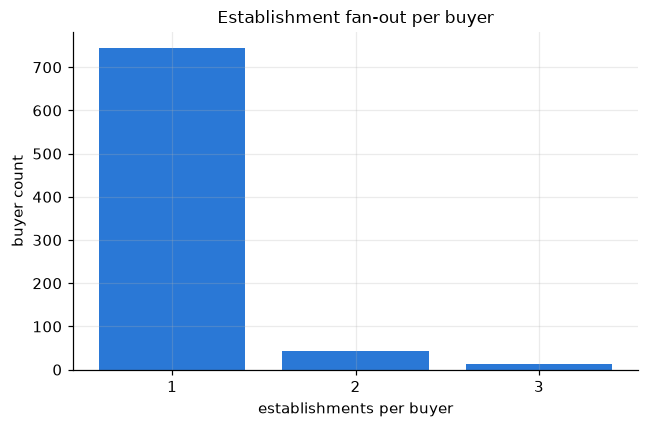

In [3]:
per_buyer = establishments.groupby("buyer_id_true").size()

fig, ax = plt.subplots(figsize=(6, 4))
counts = per_buyer.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color=BLUE)
ax.set_xlabel("establishments per buyer")
ax.set_ylabel("buyer count")
ax.set_title("Establishment fan-out per buyer")
plt.tight_layout()
plt.show()

## Stage 3 - Needs: what each buyer is buying, and how often

`needs.py::generate_latent_needs` draws, per buyer, a Poisson count of
needs whose expected value is allocated **continuously** from the buyer's
`activity_rate` (not from the 3-bucket tier average) -- this is what lets a
handful of very active buyers create dense candidate neighbourhoods later.
Each need then gets a CPV division (from the empirical
`calib_cpv_division_coverage.csv` distribution) and a duration profile drawn
`lognormal(mean=log(12), sigma=0.7)`, clipped to [1, 120] months.

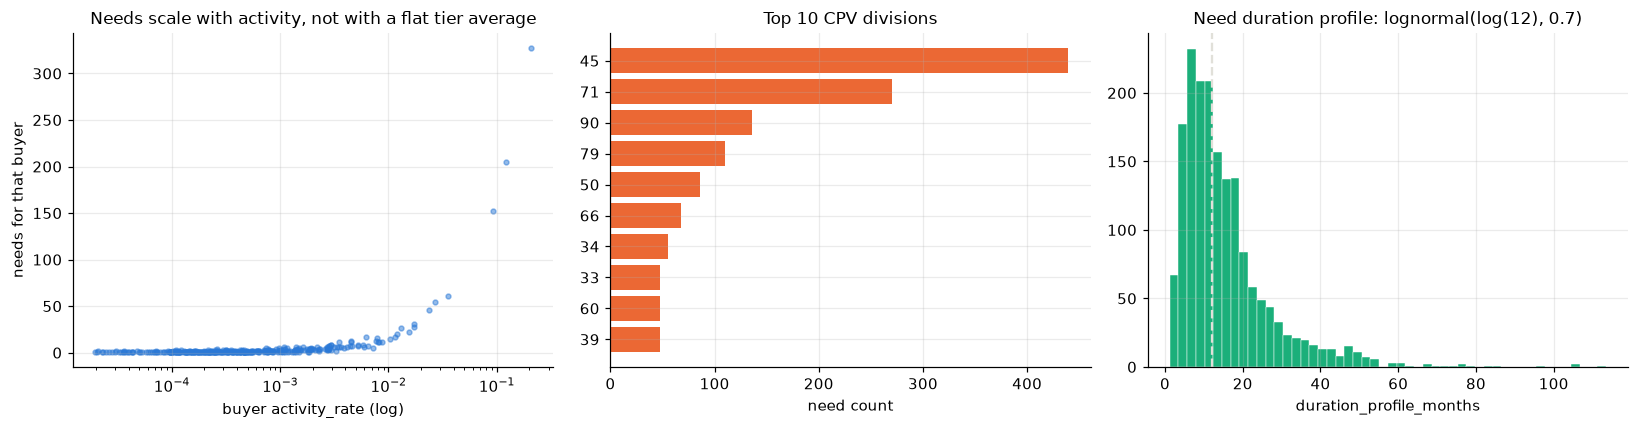

In [4]:
needs_per_buyer = needs.groupby("buyer_id_true").size()
activity_by_buyer = buyers.set_index("buyer_id_true")["activity_rate"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(activity_by_buyer.reindex(needs_per_buyer.index), needs_per_buyer.values,
                s=10, color=BLUE, alpha=0.5)
axes[0].set_xscale("log")
axes[0].set_xlabel("buyer activity_rate (log)")
axes[0].set_ylabel("needs for that buyer")
axes[0].set_title("Needs scale with activity, not with a flat tier average")

division_counts = needs["cpv_true"].str[:2].value_counts().head(10)
axes[1].barh(division_counts.index.astype(str)[::-1], division_counts.values[::-1], color=ORANGE)
axes[1].set_xlabel("need count")
axes[1].set_title("Top 10 CPV divisions")

axes[2].hist(needs["duration_profile_months"], bins=50, color=AQUA, edgecolor="white", linewidth=0.3)
axes[2].axvline(12, color=GRID, linestyle="--", linewidth=1.5)
axes[2].set_xlabel("duration_profile_months")
axes[2].set_title("Need duration profile: lognormal(log(12), 0.7)")

plt.tight_layout()
plt.show()

## Stage 4 - Cycles: the actual "survival time" step

This is where the renewal/survival quantity is born. For each need, cycle 1
starts inside the buyer's active window; every following cycle exists only
if a Bernoulli successor draw (using the need's `recurrence_propensity`,
scenario base `recurrence.base_recurrence_propensity = 0.40`) succeeds
**and** the resulting start date still falls inside the observation window
(`cycles.py::generate_latent_cycles`). The gap to the next cycle is drawn
from a **normal distribution truncated below at 1 month**,
`mean=18.0, sd=9.0` months (`recurrence.cycle_gap_distribution` in
`config/synthetic/scenarios/central_provisional.yaml`) -- deliberately
centered far outside the production linkage pipeline's own 6-month blocking
window, so a meaningful share of true successors fall outside it by design.

A subset of CPV divisions (`32, 35, 48, 72`) instead draw a much tighter
"near-window" gap (`mean=2.0, sd=2.0`, clipped to `[0.1, 6.0]`) to create a
realistic near-term candidate environment for those divisions. The exact
numbers are read live from the scenario config in the code cell below, not
retyped here.

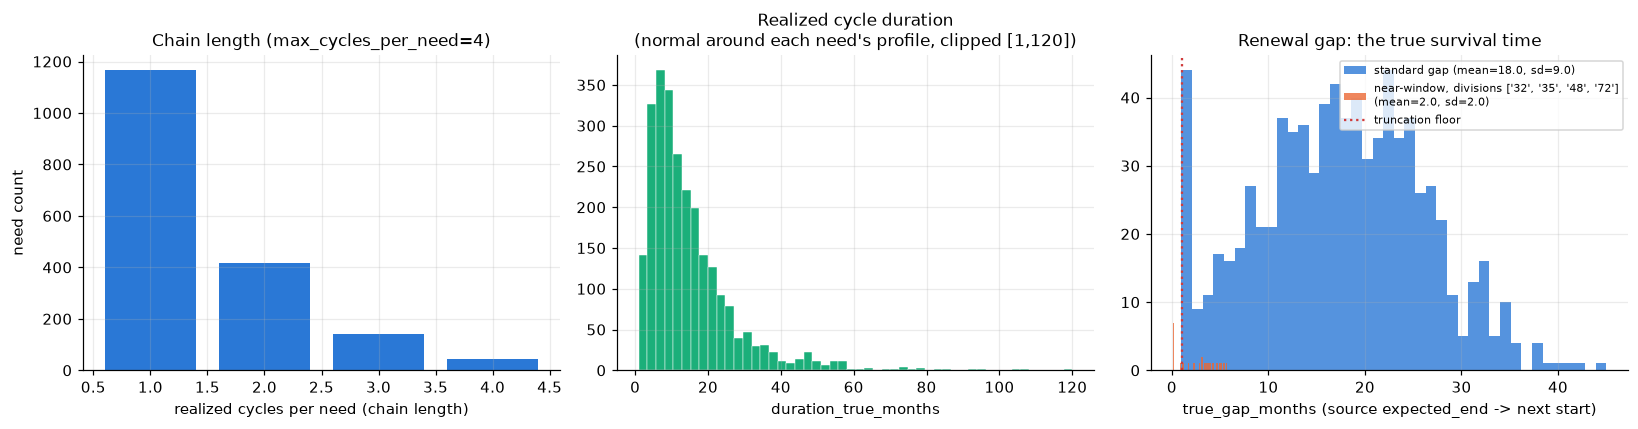

base_recurrence_propensity = 0.4 (jittered per-need by beta(4,4) rescaled to ~[0.7, 1.3])


In [5]:
gap_dist = scenario.recurrence.cycle_gap_distribution
nw_cfg = scenario.recurrence.scoped_candidate_environment
nw_dist = nw_cfg.near_window_distribution
scoped_divisions = set(nw_cfg.cpv_divisions)

chain_length = cycles.groupby("need_id_true")["cycle_number"].max()

need_division = needs.set_index("need_id_true")["cpv_true"].str[:2]
gaps = true_relations[true_relations["relation_type"] == "NEXT_CYCLE"].merge(
    cycles[["cycle_id_true", "need_id_true"]], left_on="source_cycle_id", right_on="cycle_id_true",
)
gaps["division"] = gaps["need_id_true"].map(need_division)
gaps["is_scoped"] = gaps["division"].isin(scoped_divisions)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(*zip(*sorted(chain_length.value_counts().items())), color=BLUE)
axes[0].set_xlabel("realized cycles per need (chain length)")
axes[0].set_ylabel("need count")
axes[0].set_title(f"Chain length (max_cycles_per_need={scenario.recurrence.max_cycles_per_need})")

axes[1].hist(cycles["duration_true_months"], bins=50, color=AQUA, edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("duration_true_months")
axes[1].set_title("Realized cycle duration\n(normal around each need's profile, clipped [1,120])")

axes[2].hist(gaps.loc[~gaps["is_scoped"], "true_gap_months"], bins=40, color=BLUE, alpha=0.8,
             label=f"standard gap (mean={gap_dist.mean_months}, sd={gap_dist.sd_months})")
axes[2].hist(gaps.loc[gaps["is_scoped"], "true_gap_months"], bins=40, color=ORANGE, alpha=0.8,
             label=f"near-window, divisions {sorted(scoped_divisions)}\n(mean={nw_dist.mean_months}, sd={nw_dist.sd_months})")
axes[2].axvline(gap_dist.min_months, color=CRIT, linestyle=":", linewidth=1.5, label="truncation floor")
axes[2].set_xlabel("true_gap_months (source expected_end -> next start)")
axes[2].set_title("Renewal gap: the true survival time")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

print(f"base_recurrence_propensity = {scenario.recurrence.base_recurrence_propensity} "
      f"(jittered per-need by beta(4,4) rescaled to ~[0.7, 1.3])")

## Stage 5 - Relations: where event vs. censoring is decided

`relations.py` derives exactly one outgoing edge per cycle from `cycles`
alone: `NEXT_CYCLE` (with `true_gap_months`) if a next cycle was realized,
else `NO_SUCCESSOR`. `NO_SUCCESSOR` bundles three different generator
reasons (successor draw failed, `max_cycles_per_need` hit, or the next start
fell past the observation window -- i.e. **administrative right-censoring**)
into one label; the ontology deliberately does not distinguish them
downstream.

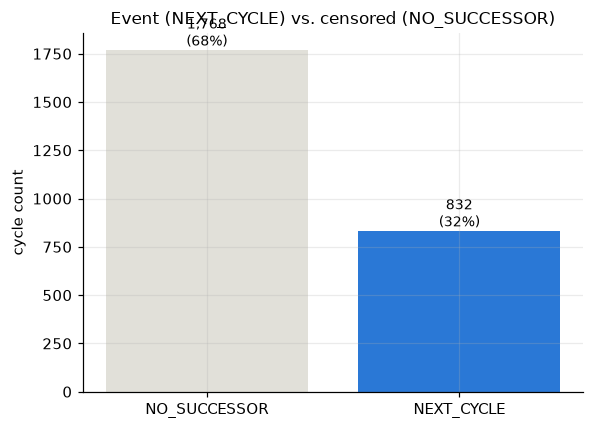

In [6]:
rel_counts = true_relations["relation_type"].value_counts()
total = rel_counts.sum()

fig, ax = plt.subplots(figsize=(5.5, 4))
colors = {"NEXT_CYCLE": BLUE, "NO_SUCCESSOR": GRID}
bars = ax.bar(rel_counts.index, rel_counts.values, color=[colors.get(k, BLUE) for k in rel_counts.index])
for bar, v in zip(bars, rel_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}\n({v/total:.0%})", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("cycle count")
ax.set_title("Event (NEXT_CYCLE) vs. censored (NO_SUCCESSOR)")
plt.tight_layout()
plt.show()

## Stage 6 - Notices: CALL / AWARD pairs

Each cycle emits a CALL notice (`APPEL_OFFRE`) always, and an AWARD notice
(`ATTRIBUTION`) with probability set by the empirical
`notice_types.mix` ratio -- so most "notice families" are size-2, some are
size-1 (`notices.py::generate_notice_families_and_clean_notices`).

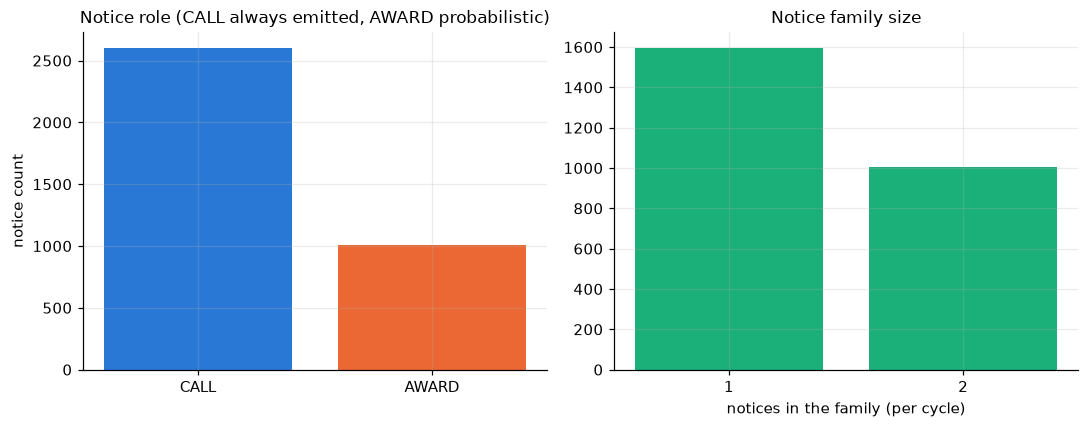

In [7]:
role_counts = clean_notices["role"].value_counts()
family_size = notice_family_membership.groupby("cycle_id_true").size().value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(role_counts.index, role_counts.values, color=[BLUE, ORANGE])
axes[0].set_title("Notice role (CALL always emitted, AWARD probabilistic)")
axes[0].set_ylabel("notice count")

axes[1].bar(family_size.index.astype(str), family_size.values, color=AQUA)
axes[1].set_xlabel("notices in the family (per cycle)")
axes[1].set_title("Notice family size")
plt.tight_layout()
plt.show()

## Stage 7 - Corruption: co-occurring noise, not independent per-field errors

Before any field is corrupted, every notice is assigned one latent
`quality_class` (HIGH/MEDIUM/LOW, mix `{HIGH: 0.30, MEDIUM: 0.45, LOW: 0.25}`
here) correlated with its buyer's `identifier_quality_propensity`
(`missingness.py::assign_quality_class`). A shared severity multiplier
(`{'HIGH': 0.35, 'MEDIUM': 1.0, 'LOW': 2.2}` for identifiers/CPV/text, a
flatter `{'HIGH': 0.89, 'MEDIUM': 1.0, 'LOW': 1.15}` for duration) then scales
every field's base corruption rate at once -- this is deliberately **not**
five independent Bernoulli draws per notice (Lam et al.'s corruption-design
principle), so a bad-quality notice tends to have several corrupted fields
together, not one.

The cell below re-derives `quality_class` with an independent RNG purely to
show the mechanism (buyer propensity -> class); it is not the exact
per-notice assignment used inside `generate_observed_world` above, since that
one is drawn on a different, shared corruption RNG stream.

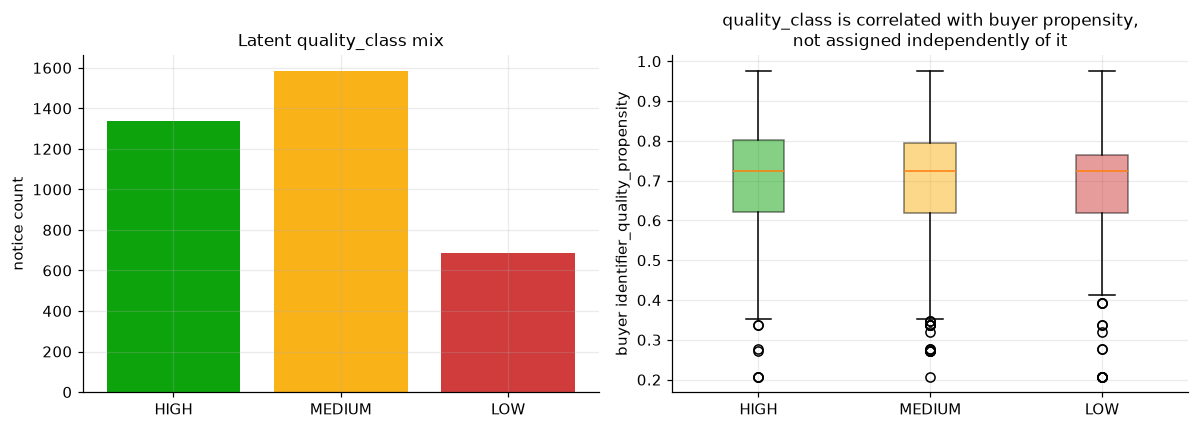

In [8]:
demo_quality_class = assign_quality_class(clean_notices, buyers, scenario, np.random.default_rng(999))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

class_order = ["HIGH", "MEDIUM", "LOW"]
class_counts = demo_quality_class.value_counts().reindex(class_order)
axes[0].bar(class_counts.index, class_counts.values, color=[GOOD, WARN, CRIT])
axes[0].set_title("Latent quality_class mix")
axes[0].set_ylabel("notice count")

prop_by_notice = clean_notices["buyer_id_true"].map(buyers.set_index("buyer_id_true")["identifier_quality_propensity"])
box_data = [prop_by_notice[demo_quality_class == c].dropna() for c in class_order]
bp = axes[1].boxplot(box_data, tick_labels=class_order, patch_artist=True)
for patch, c in zip(bp["boxes"], [GOOD, WARN, CRIT]):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)
axes[1].set_ylabel("buyer identifier_quality_propensity")
axes[1].set_title("quality_class is correlated with buyer propensity,\nnot assigned independently of it")

plt.tight_layout()
plt.show()

Now the actual corruption log from the run above: what fields get
corrupted, how severely, and -- the key co-occurrence check -- how many
distinct fields get corrupted **on the same notice**.

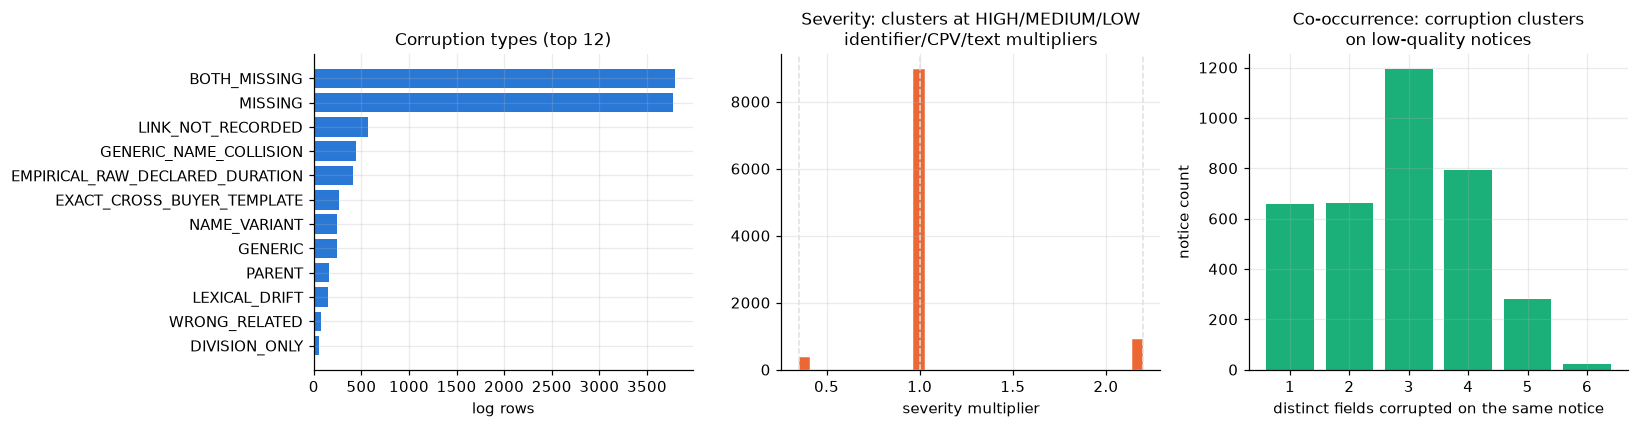

In [9]:
fields_per_notice = corruption_log.groupby("notice_id_synthetic").size()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

type_counts = corruption_log["corruption_type"].value_counts().head(12)
axes[0].barh(type_counts.index[::-1], type_counts.values[::-1], color=BLUE)
axes[0].set_xlabel("log rows")
axes[0].set_title("Corruption types (top 12)")

axes[1].hist(corruption_log["severity"], bins=30, color=ORANGE, edgecolor="white", linewidth=0.3)
for cls, mult in SEVERITY_MULTIPLIER.items():
    axes[1].axvline(mult, color=GRID, linestyle="--", linewidth=1)
axes[1].set_xlabel("severity multiplier")
axes[1].set_title("Severity: clusters at HIGH/MEDIUM/LOW\nidentifier/CPV/text multipliers")

axes[2].bar(*zip(*sorted(fields_per_notice.value_counts().items())), color=AQUA)
axes[2].set_xlabel("distinct fields corrupted on the same notice")
axes[2].set_ylabel("notice count")
axes[2].set_title("Co-occurrence: corruption clusters\non low-quality notices")

plt.tight_layout()
plt.show()

## Stage 8 - Export: truth stays out of the observed table

`schemas.assert_no_truth_leakage` enforces that no `_true`-suffixed or
truth-aliased column (buyer/need/cycle id, `quality_class`, `relation_type`,
...) ever reaches `observed_notices.parquet`. Layer 1/2 linkage code only
ever sees the right-hand column set below; every left-hand column exists
solely for later fidelity/validation checks.

Truth-only columns (never leave clean_notices):
  buyer_id_true
  buyer_name_true
  cpv_true
  cycle_id_true
  department_true
  duration_true_months
  establishment_id_true
  linked_call_notice_id_true
  need_id_true
  notice_type_true
  objet_true
  publication_date_true
  role
  schema_family_true
  siren_true
  siret_true

Observed-only columns (corrupted/renamed views of the above):
  buyer_name_raw
  buyer_siren_raw
  buyer_siret_raw
  code_departement
  cpv_clean
  declared_duration_months
  linked_call_notice_id
  notice_type_normalized
  objet_clean
  publication_date
  schema_family

Shared columns: ['notice_id_synthetic']


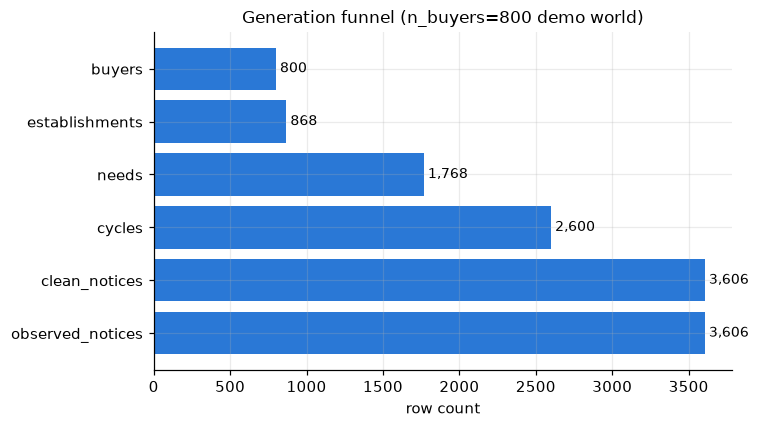

In [10]:
clean_only = sorted(set(clean_notices.columns) - set(observed.columns))
observed_only = sorted(set(observed.columns) - set(clean_notices.columns))
shared = sorted(set(clean_notices.columns) & set(observed.columns))

print("Truth-only columns (never leave clean_notices):")
for c in clean_only:
    print(f"  {c}")
print("\nObserved-only columns (corrupted/renamed views of the above):")
for c in observed_only:
    print(f"  {c}")
print(f"\nShared columns: {shared}")

funnel = pd.Series({
    "buyers": len(buyers), "establishments": len(establishments), "needs": len(needs),
    "cycles": len(cycles), "clean_notices": len(clean_notices), "observed_notices": len(observed),
})
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(funnel.index[::-1], funnel.values[::-1], color=BLUE)
for i, v in enumerate(funnel.values[::-1]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
ax.set_xlabel("row count")
ax.set_title(f"Generation funnel (n_buyers={N_BUYERS_DEMO} demo world)")
plt.tight_layout()
plt.show()

## Putting it together: what feeds the survival model

`true_relations` already carries the survival quantity in its rawest form:
`NEXT_CYCLE` rows are events at `true_gap_months`; `NO_SUCCESSOR` rows are
censored at whatever time remains between the cycle's expected end and the
observation window boundary. This ground truth is used only for evaluation
-- the production linkage pipeline (`src/boamp/survival/datasets.py`) never
sees it; it re-derives event/censoring from `observed_notices` plus the
linkage algorithm's accepted links instead. The Kaplan-Meier curve below is
purely descriptive of this demo world's *ground truth*, not a model fit.

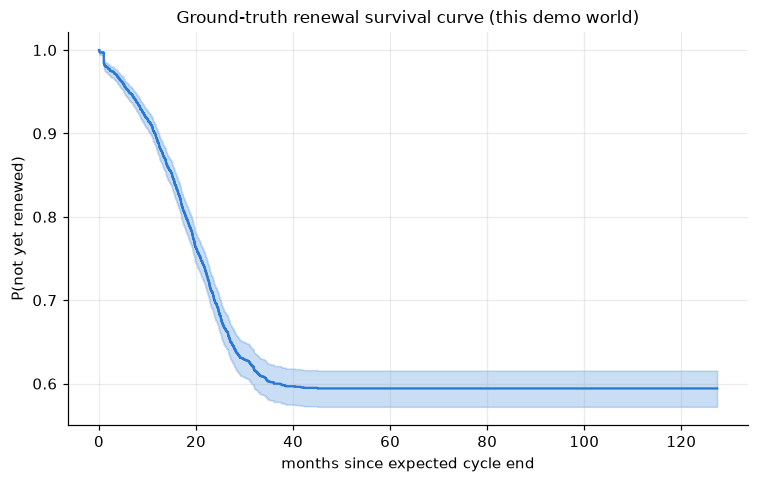

events=832, censored=1768


In [11]:
event_rows = true_relations[true_relations["relation_type"] == "NEXT_CYCLE"].copy()
event_rows["time"] = event_rows["true_gap_months"]
event_rows["event"] = 1

censored_rows = true_relations[true_relations["relation_type"] == "NO_SUCCESSOR"].merge(
    cycles[["cycle_id_true", "expected_end_true"]], left_on="source_cycle_id", right_on="cycle_id_true",
)
censored_rows["time"] = ((observation_end - censored_rows["expected_end_true"]).dt.days / 30.44).clip(lower=0)
censored_rows["event"] = 0

survival_demo = pd.concat([event_rows[["time", "event"]], censored_rows[["time", "event"]]], ignore_index=True)

kmf = KaplanMeierFitter()
kmf.fit(survival_demo["time"], event_observed=survival_demo["event"])

fig, ax = plt.subplots(figsize=(7, 4.5))
kmf.plot_survival_function(ax=ax, color=BLUE, ci_show=True)
ax.set_xlabel("months since expected cycle end")
ax.set_ylabel("P(not yet renewed)")
ax.set_title("Ground-truth renewal survival curve (this demo world)")
ax.get_legend().remove()
plt.tight_layout()
plt.show()

print(f"events={int(survival_demo['event'].sum())}, censored={int((1 - survival_demo['event']).sum())}")

## Summary

| # | Stage | Mechanism | Code |
|---|-------|-----------|------|
| 1 | Buyers | Pareto activity -> tiers | `synthetic/buyers.py` |
| 2 | Establishments | fan-out per buyer | `synthetic/establishments.py` |
| 3 | Needs | Poisson count (activity-weighted), CPV division, lognormal duration | `synthetic/needs.py` |
| 4 | Cycles | truncated-normal renewal gap, admin right-censoring at window boundary | `synthetic/cycles.py` |
| 5 | Relations | derived NEXT_CYCLE / NO_SUCCESSOR | `synthetic/relations.py` |
| 6 | Notices | CALL always, AWARD probabilistic | `synthetic/notices.py` |
| 7 | Corruption | shared quality_class -> co-occurring field noise | `synthetic/missingness.py`, `synthetic/corruption.py` |
| 8 | Export | truth columns stripped, schema-validated | `synthetic/pipeline.py`, `synthetic/schemas.py` |

For the full spec and parameter provenance (empirical vs. scenario
assumption vs. algorithm parameter), see
`docs/synthetic_benchmark_dgp_specification.md` and
`registries/parameter_registry.csv`. For calibration diagnostics against the
real corpus, see `notebooks/04_synthetic_benchmark_calibration.ipynb` and
`notebooks/11_synthetic_real_benchmark_comparison.ipynb`.
